<a href="https://colab.research.google.com/github/nhjung-phd/TimeSeriesAnalysis/blob/main/notebooks/22_rnn_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🎯 학습목표
- RNN 기반 시계열 예측 파이프라인(데이터 → 시간순 분할 → 스케일링 → 윈도우 → 학습 → 평가)을 이해한다.
- `time_steps=1`인 한계 사례와 과거 10거래일을 사용하는 Sliding Window RNN의 차이를 설명한다.
- Train/Validation/Test의 역할, Naïve 기준모형, 외표본 평가와 과적합 위험을 확인한다.


### 🧭 실습 로드맵
1. 단일 타임스텝 RNN의 한계 확인
2. **과거 10거래일 종가 → 다음 거래일 종가** 예측(Sliding Window)
3. 검증기간만 사용하는 KerasTuner
4. Full-series(내표본), Fixed-origin, Rolling, Expanding, Naïve 비교

각 실습은 독립적인 예시이며, 실제 예측에는 슬라이딩 윈도우 기반 실습을 우선 사용합니다.


### ⚠️ 시계열 실습의 공통 검증 원칙
- **미래정보 누수 방지:** 정규화는 훈련 구간으로만 `fit`하고 이후 구간에는 `transform`합니다.
- **시간순 분할:** Train/Validation/Test를 시간 순서로 나눕니다. 최종 Test는 튜닝·Early Stopping에 사용하지 않습니다.
- **예측 시점:** 시점 `t`의 종가를 예측할 때 입력에는 `t-1`까지 관측된 값만 들어갑니다.
- **역정규화:** 평가 지표는 실제 주가(USD) 단위로 산출합니다.
- **기준모형:** 동일한 외표본 날짜에 Naïve(전 거래일 종가)를 함께 평가합니다.

**주의:** 주가의 다음 거래일 종가 예측은 한 거래일씩 관측값이 새로 들어오는 *one-step-ahead* 평가입니다. 여러 거래일을 한 번에 미리 예측하는 과제와는 다릅니다.


# RNN 기반 예측



# ✅ 🔹 RNN 기반 테슬라 주가 예측 코드

## 1) 데이터 수집 / 단일 타임스텝 실습
- 기존의 날짜(`Day`) 기반 입력 구조를 **한계 사례**로 유지합니다.
- `time_steps=1`은 이전 은닉상태의 시계열 패턴을 충분히 활용하지 못하며, 사실상 단일 입력 기반 비선형 추세 근사에 가깝습니다.
- 기간은 `2022-01-01`부터 `2024-01-01` 직전 거래일까지의 **약 2년**으로, '최근 1년' 실습이 아닙니다.


단일 타임스텝 실습: 시간 의존성을 충분히 학습하는 RNN 예시가 아닙니다.
                Model      MAE     RMSE
0  RNN (time_steps=1)  15.2744  19.4427
1               Naive   5.2946   7.1104


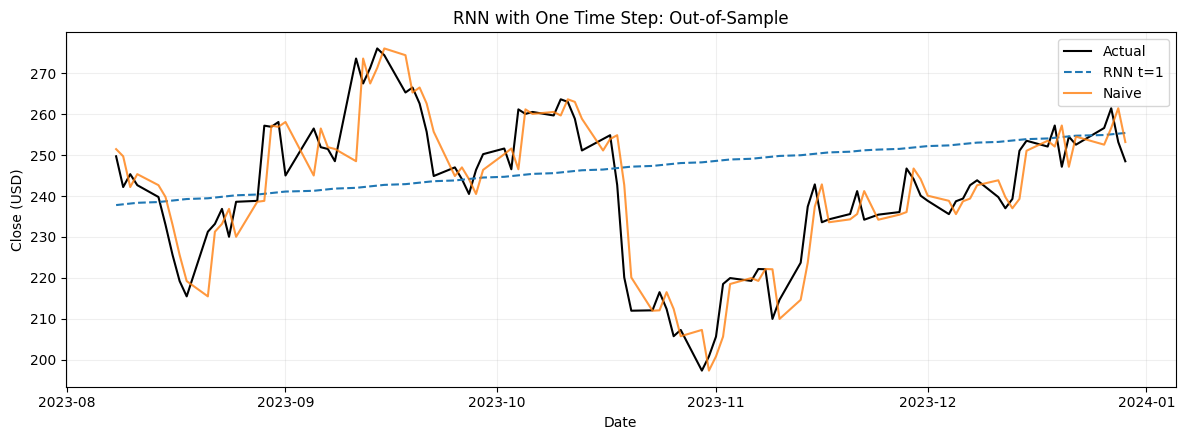

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

def load_tsla_rnn():
    # auto_adjust=True로 분할/배당 조정 가격을 사용; 마지막 날짜는 제외(end exclusive)
    raw = yf.download('TSLA', start='2022-01-01', end='2024-01-01',
                      auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError('TSLA 다운로드 실패 또는 데이터 없음: 인터넷 연결/기간을 확인하세요.')
    # yfinance 버전에 따라 ('Close','TSLA') 같은 MultiIndex가 반환될 수 있음
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    series = pd.to_numeric(close, errors='coerce').dropna().sort_index()
    out = series.rename('Close').reset_index()
    out.columns = ['Date', 'Close']
    if len(out) < 130:
        raise ValueError('학습/검증/시험 및 윈도우에 충분한 데이터가 없습니다.')
    return out

def make_rnn_windows(arr, lookback):
    # X[i] = 직전 lookback개 종가, y[i] = 바로 다음 거래일 종가
    X = np.stack([arr[i-lookback:i] for i in range(lookback, len(arr))]).astype('float32')
    y = arr[lookback:].astype('float32')
    return X, y

def report_rnn(actual, pred, naive, title):
    actual, pred, naive = [np.asarray(a).reshape(-1) for a in (actual, pred, naive)]
    return pd.DataFrame([
        {'Model': title, 'MAE': mean_absolute_error(actual, pred),
         'RMSE': np.sqrt(mean_squared_error(actual,pred))},
        {'Model': 'Naive', 'MAE': mean_absolute_error(actual, naive),
         'RMSE': np.sqrt(mean_squared_error(actual,naive))}
    ]).round(4)

# --- 실습 A: 날짜 1개를 입력하는 RNN (학습용 한계 사례) ---
df = load_tsla_rnn()
N = len(df)
train_end, val_end = int(N*0.60), int(N*0.80)
X_raw = np.arange(N, dtype=float).reshape(-1,1)  # 거래일 번호: 종가 이력은 입력하지 않음
y_raw = df[['Close']].to_numpy(dtype=float)
scaler_X = MinMaxScaler().fit(X_raw[:train_end])
scaler_y = MinMaxScaler().fit(y_raw[:train_end])
Xs = scaler_X.transform(X_raw).reshape(N,1,1)
ys = scaler_y.transform(y_raw)
X_train, X_val, X_test = Xs[:train_end], Xs[train_end:val_end], Xs[val_end:]
y_train, y_val, y_test = ys[:train_end], ys[train_end:val_end], ys[val_end:]
model = Sequential([Input(shape=(1,1)), SimpleRNN(50, activation='tanh'), Dense(1)])
model.compile(optimizer='adam', loss='mse')
history = model.fit(X_train, y_train, epochs=100, batch_size=16, shuffle=False,
                    validation_data=(X_val,y_val),
                    callbacks=[EarlyStopping(monitor='val_loss', patience=10,
                                             restore_best_weights=True)], verbose=0)
train_pred = scaler_y.inverse_transform(model.predict(X_train,verbose=0)).ravel()
test_pred = scaler_y.inverse_transform(model.predict(X_test,verbose=0)).ravel()
train_true, test_true = y_raw[:train_end,0], y_raw[val_end:,0]
naive = y_raw[val_end-1:-1,0]  # Test 각 날짜의 직전 실제 종가
print('단일 타임스텝 실습: 시간 의존성을 충분히 학습하는 RNN 예시가 아닙니다.')
print(report_rnn(test_true, test_pred, naive, 'RNN (time_steps=1)'))
fig,ax=plt.subplots(figsize=(12,4.5))
ax.plot(df['Date'].iloc[val_end:],test_true,label='Actual',color='black')
ax.plot(df['Date'].iloc[val_end:],test_pred,label='RNN t=1',linestyle='--')
ax.plot(df['Date'].iloc[val_end:],naive,label='Naive',alpha=.8)
ax.set(title='RNN with One Time Step: Out-of-Sample',xlabel='Date',ylabel='Close (USD)')
ax.legend();ax.grid(alpha=.2);plt.tight_layout();plt.show()


# ✅ 🚀 Sliding Window 적용된 RNN 기반 테슬라 주가 예측 코드:

## 2) 과거 10거래일 → 다음 거래일 예측
- 날짜 기반 입력 대신 **종가의 과거 10개 관측치**를 `(samples, 10, 1)`로 묶습니다.
- 60% Train, 20% Validation, 20% Test를 목표 날짜 기준으로 나눕니다.
- 이전 기간 관측치는 이후 기간 첫 예측의 입력 이력으로 사용할 수 있지만, 해당 예측 날짜의 종가는 입력하지 않습니다.


Test observations: 101 Input shape: (290, 10, 1)
         Model     MAE     RMSE
0  Sliding RNN  9.7235  11.8685
1        Naive  5.2946   7.1104


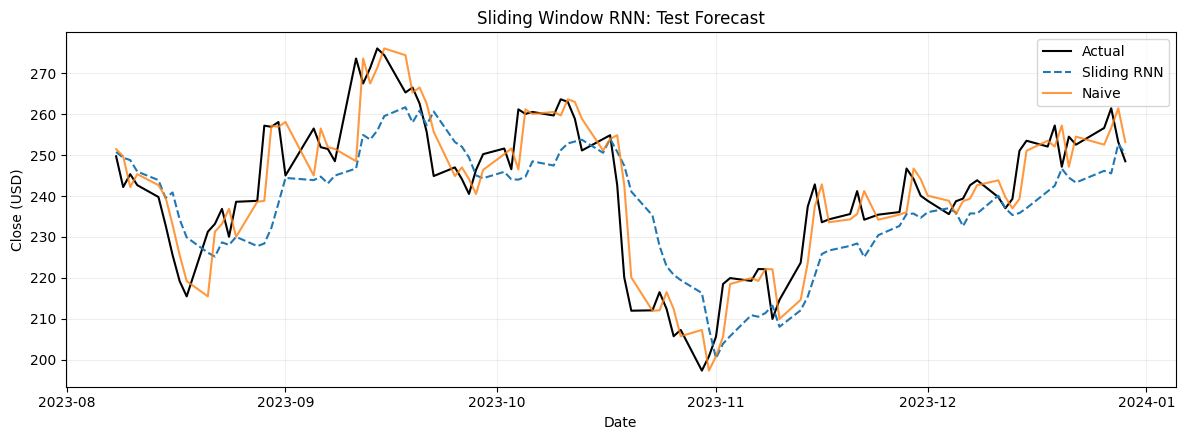

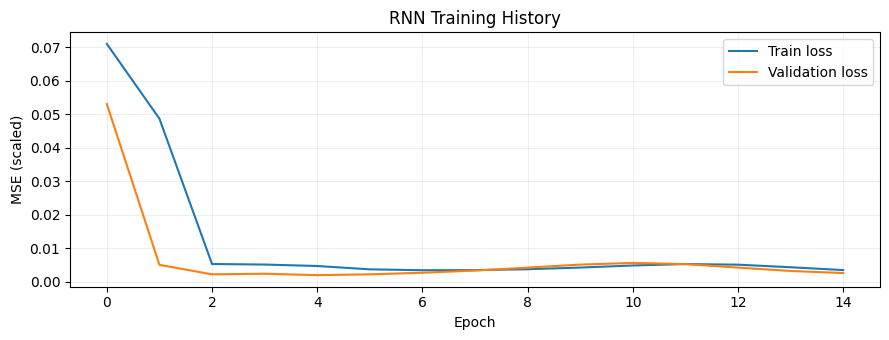

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

def load_tsla_rnn():
    # auto_adjust=True로 분할/배당 조정 가격을 사용; 마지막 날짜는 제외(end exclusive)
    raw = yf.download('TSLA', start='2022-01-01', end='2024-01-01',
                      auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError('TSLA 다운로드 실패 또는 데이터 없음: 인터넷 연결/기간을 확인하세요.')
    # yfinance 버전에 따라 ('Close','TSLA') 같은 MultiIndex가 반환될 수 있음
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    series = pd.to_numeric(close, errors='coerce').dropna().sort_index()
    out = series.rename('Close').reset_index()
    out.columns = ['Date', 'Close']
    if len(out) < 130:
        raise ValueError('학습/검증/시험 및 윈도우에 충분한 데이터가 없습니다.')
    return out

def make_rnn_windows(arr, lookback):
    # X[i] = 직전 lookback개 종가, y[i] = 바로 다음 거래일 종가
    X = np.stack([arr[i-lookback:i] for i in range(lookback, len(arr))]).astype('float32')
    y = arr[lookback:].astype('float32')
    return X, y

def report_rnn(actual, pred, naive, title):
    actual, pred, naive = [np.asarray(a).reshape(-1) for a in (actual, pred, naive)]
    return pd.DataFrame([
        {'Model': title, 'MAE': mean_absolute_error(actual, pred),
         'RMSE': np.sqrt(mean_squared_error(actual,pred))},
        {'Model': 'Naive', 'MAE': mean_absolute_error(actual, naive),
         'RMSE': np.sqrt(mean_squared_error(actual,naive))}
    ]).round(4)

# --- 실습 B: Sliding Window RNN ---
df = load_tsla_rnn()
close = df[['Close']].to_numpy(dtype=float)
N = len(close); train_end, val_end = int(N*.60), int(N*.80)
window_size = 10
# scaler는 예측 대상의 최초 훈련 구간만 보고 학습
scaler = MinMaxScaler().fit(close[:train_end])
scaled = scaler.transform(close)
X, y = make_rnn_windows(scaled, window_size)
# y의 타깃 날짜 원본 행 위치 = window_size + i
positions = np.arange(window_size,N)
tr, va, te = positions < train_end, (positions>=train_end)&(positions<val_end), positions>=val_end
X_train,y_train = X[tr],y[tr]
X_val,y_val = X[va],y[va]
X_test,y_test = X[te],y[te]
model = Sequential([Input(shape=(window_size,1)),SimpleRNN(50,activation='tanh'),Dense(1)])
model.compile(optimizer='adam',loss='mse')
history = model.fit(X_train,y_train,epochs=100,batch_size=16,shuffle=False,
                    validation_data=(X_val,y_val),
                    callbacks=[EarlyStopping(monitor='val_loss',patience=10,
                                             restore_best_weights=True)],verbose=0)
pred = scaler.inverse_transform(model.predict(X_test,verbose=0)).ravel()
actual = close[positions[te],0]
naive = close[positions[te]-1,0]
print('Test observations:',len(actual),'Input shape:',X_train.shape)
print(report_rnn(actual,pred,naive,'Sliding RNN'))
dates=df['Date'].iloc[positions[te]]
fig,ax=plt.subplots(figsize=(12,4.5))
ax.plot(dates,actual,label='Actual',color='black')
ax.plot(dates,pred,label='Sliding RNN',linestyle='--')
ax.plot(dates,naive,label='Naive',alpha=.8)
ax.set(title='Sliding Window RNN: Test Forecast',xlabel='Date',ylabel='Close (USD)')
ax.legend();ax.grid(alpha=.2);plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(9,3.5))
ax.plot(history.history['loss'],label='Train loss')
ax.plot(history.history['val_loss'],label='Validation loss')
ax.set(title='RNN Training History',xlabel='Epoch',ylabel='MSE (scaled)')
ax.legend();ax.grid(alpha=.2);plt.tight_layout();plt.show()


# ✅ 🚀 하이퍼파라미터 튜닝이 적용된 RNN 기반 테슬라 주가 예측 코드

In [3]:
!pip install keras-tuner --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.5 MB/s eta 0:00:00


## 3) 하이퍼파라미터 튜닝 실습
- KerasTuner는 **검증기간 오차만으로** 유닛 수·활성화 함수·학습률을 고릅니다.
- 최종 테스트 구간의 실제값은 모델 선택 및 Early Stopping에 사용하지 않습니다.
- 셀 실행 시 별도 실습용 TSLA 데이터를 다시 준비합니다.


Chosen hyperparameters from Validation only: {'units': 64, 'activation': 'relu', 'learning_rate': 0.0001}


       Model     MAE    RMSE
0  Tuned RNN  6.3228  8.2592
1      Naive  5.2946  7.1104


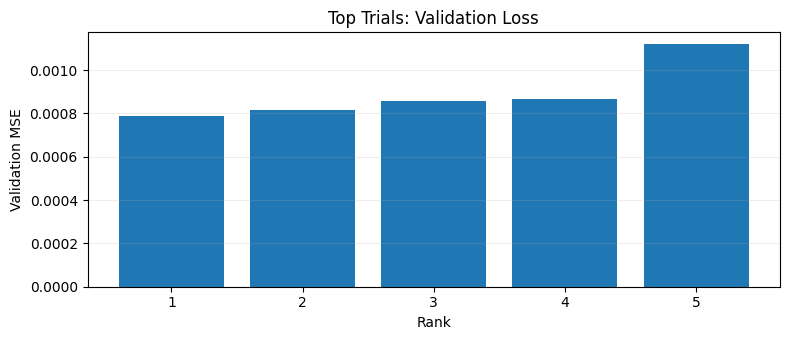

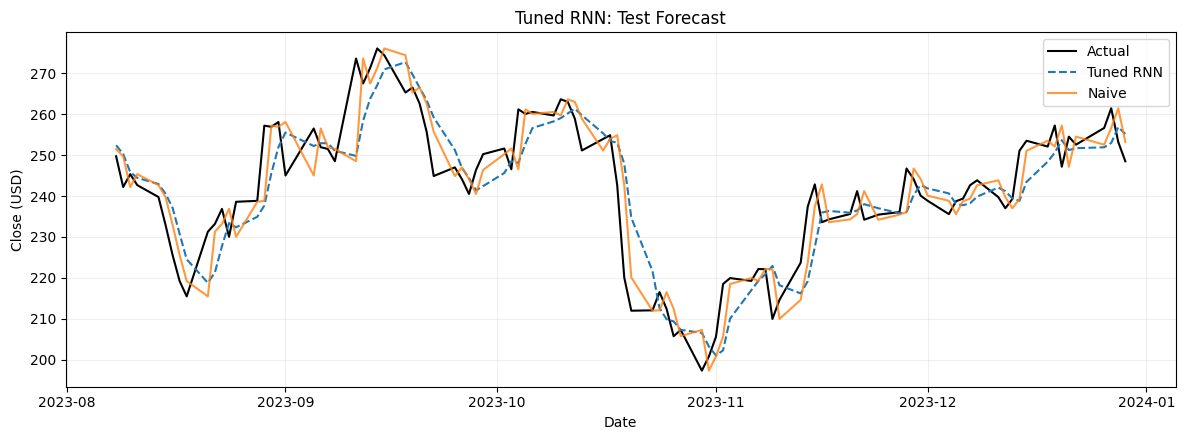

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

def load_tsla_rnn():
    # auto_adjust=True로 분할/배당 조정 가격을 사용; 마지막 날짜는 제외(end exclusive)
    raw = yf.download('TSLA', start='2022-01-01', end='2024-01-01',
                      auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError('TSLA 다운로드 실패 또는 데이터 없음: 인터넷 연결/기간을 확인하세요.')
    # yfinance 버전에 따라 ('Close','TSLA') 같은 MultiIndex가 반환될 수 있음
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    series = pd.to_numeric(close, errors='coerce').dropna().sort_index()
    out = series.rename('Close').reset_index()
    out.columns = ['Date', 'Close']
    if len(out) < 130:
        raise ValueError('학습/검증/시험 및 윈도우에 충분한 데이터가 없습니다.')
    return out

def make_rnn_windows(arr, lookback):
    # X[i] = 직전 lookback개 종가, y[i] = 바로 다음 거래일 종가
    X = np.stack([arr[i-lookback:i] for i in range(lookback, len(arr))]).astype('float32')
    y = arr[lookback:].astype('float32')
    return X, y

def report_rnn(actual, pred, naive, title):
    actual, pred, naive = [np.asarray(a).reshape(-1) for a in (actual, pred, naive)]
    return pd.DataFrame([
        {'Model': title, 'MAE': mean_absolute_error(actual, pred),
         'RMSE': np.sqrt(mean_squared_error(actual,pred))},
        {'Model': 'Naive', 'MAE': mean_absolute_error(actual, naive),
         'RMSE': np.sqrt(mean_squared_error(actual,naive))}
    ]).round(4)

import keras_tuner as kt
from tensorflow.keras.optimizers import Adam

# --- 실습 C: Sliding Window + KerasTuner ---
df = load_tsla_rnn()
close=df[['Close']].to_numpy(dtype=float)
N=len(close);train_end,val_end=int(N*.60),int(N*.80)
window_size=10
scaler=MinMaxScaler().fit(close[:train_end]);scaled=scaler.transform(close)
X,y=make_rnn_windows(scaled,window_size)
pos=np.arange(window_size,N)
tr,va,te=pos<train_end,(pos>=train_end)&(pos<val_end),pos>=val_end
X_train,y_train=X[tr],y[tr]
X_val,y_val=X[va],y[va]
X_test,y_test=X[te],y[te]

def build_model(hp):
    m=Sequential([Input(shape=(window_size,1)),
        SimpleRNN(hp.Int('units',16,128,step=16),
                  activation=hp.Choice('activation',['relu','tanh'])),Dense(1)])
    m.compile(optimizer=Adam(learning_rate=hp.Choice('learning_rate',[.001,.0005,.0001])),loss='mse')
    return m

# 기존처럼 튜닝 폴더를 매번 강제 삭제하지 않고 overwrite로 새 탐색 수행
tuner=kt.RandomSearch(build_model,objective='val_loss',max_trials=10,
                      executions_per_trial=1,overwrite=True,
                      directory='hyperparameter_tuning',project_name='Tesla_RNN_Tuning')
stop=EarlyStopping(monitor='val_loss',patience=8,restore_best_weights=True)
tuner.search(X_train,y_train,validation_data=(X_val,y_val),epochs=50,
             batch_size=16,shuffle=False,callbacks=[stop],verbose=0)
best_hps=tuner.get_best_hyperparameters(1)[0]
print('Chosen hyperparameters from Validation only:',best_hps.values)
best_model=tuner.hypermodel.build(best_hps)
history=best_model.fit(X_train,y_train,validation_data=(X_val,y_val),
                       epochs=100,batch_size=16,shuffle=False,
                       callbacks=[EarlyStopping(monitor='val_loss',patience=10,
                                                restore_best_weights=True)],verbose=0)
pred=scaler.inverse_transform(best_model.predict(X_test,verbose=0)).ravel()
actual=close[pos[te],0]; naive=close[pos[te]-1,0]
print(report_rnn(actual,pred,naive,'Tuned RNN'))
trials=tuner.oracle.get_best_trials(num_trials=5)
fig,ax=plt.subplots(figsize=(8,3.5))
ax.bar(range(1,len(trials)+1),[t.metrics.get_best_value('val_loss') for t in trials])
ax.set(title='Top Trials: Validation Loss',xlabel='Rank',ylabel='Validation MSE')
ax.grid(axis='y',alpha=.2);plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(12,4.5))
dates=df['Date'].iloc[pos[te]]
ax.plot(dates,actual,label='Actual',color='black')
ax.plot(dates,pred,label='Tuned RNN',linestyle='--')
ax.plot(dates,naive,label='Naive',alpha=.8)
ax.set(title='Tuned RNN: Test Forecast',xlabel='Date',ylabel='Close (USD)')
ax.legend();ax.grid(alpha=.2);plt.tight_layout();plt.show()


## 4) 네 가지 평가 방식 + Naïve 기준모형
- **Full-series:** 테스트 대상까지 학습에 사용한 내표본 참고값(외표본 성능으로 보고하면 안 됨)
- **Fixed-origin:** 최초 학습구간에서 한 번 학습하고 테스트 전체를 1-step 예측
- **Rolling:** 최근 일정 개수의 과거 목표값으로 RNN을 재학습
- **Expanding:** 과거 목표값을 누적해 RNN을 재학습
- **Naïve:** 바로 전 거래일의 실제 종가를 예측값으로 사용

반복 재학습을 포함하므로 시간이 걸릴 수 있습니다. 학습 횟수와 Epoch를 조절할 수 있습니다.


                  Model    MAE    RMSE          Evaluation
Full-series (in-sample) 6.0225  7.0204 In-sample reference
           Fixed-origin 5.6976  7.1165       Out-of-sample
                Rolling 5.2778  6.2778       Out-of-sample
              Expanding 8.6431 10.4109       Out-of-sample
                  Naive 4.2300  5.2689       Out-of-sample


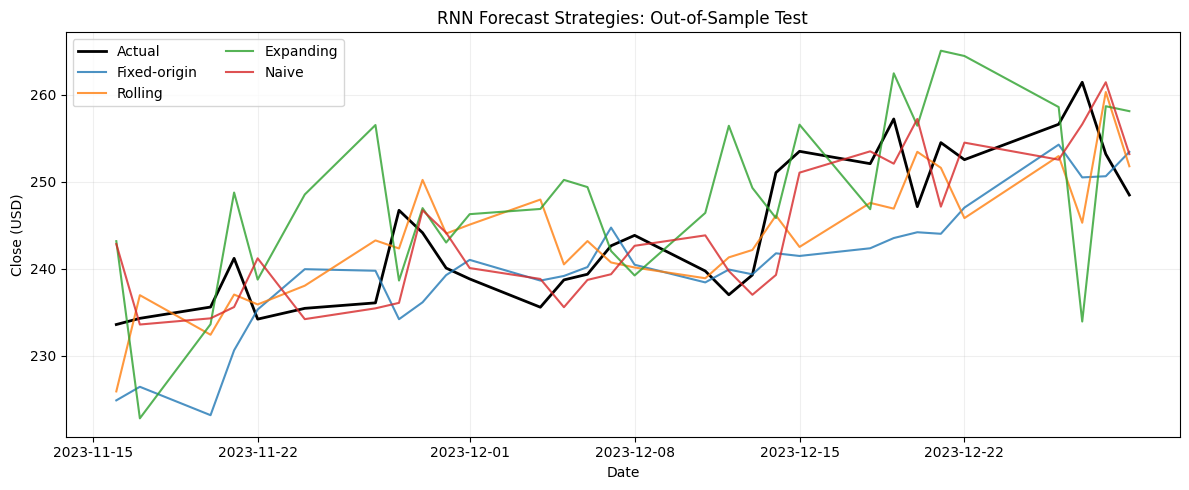

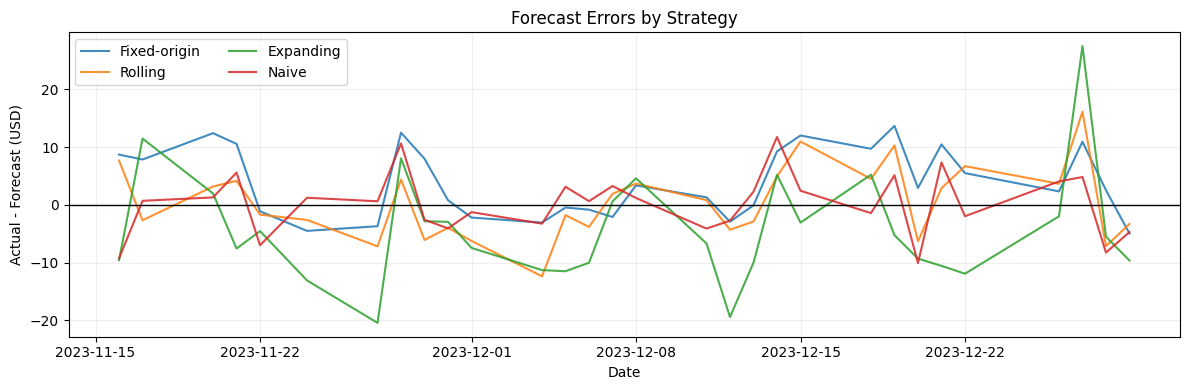

In [5]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
plt.rcParams.update({'figure.facecolor': 'white', 'axes.facecolor': 'white'})

def load_tsla_rnn():
    # auto_adjust=True로 분할/배당 조정 가격을 사용; 마지막 날짜는 제외(end exclusive)
    raw = yf.download('TSLA', start='2022-01-01', end='2024-01-01',
                      auto_adjust=True, progress=False)
    if raw.empty:
        raise ValueError('TSLA 다운로드 실패 또는 데이터 없음: 인터넷 연결/기간을 확인하세요.')
    # yfinance 버전에 따라 ('Close','TSLA') 같은 MultiIndex가 반환될 수 있음
    close = raw['Close']
    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]
    series = pd.to_numeric(close, errors='coerce').dropna().sort_index()
    out = series.rename('Close').reset_index()
    out.columns = ['Date', 'Close']
    if len(out) < 130:
        raise ValueError('학습/검증/시험 및 윈도우에 충분한 데이터가 없습니다.')
    return out

def make_rnn_windows(arr, lookback):
    # X[i] = 직전 lookback개 종가, y[i] = 바로 다음 거래일 종가
    X = np.stack([arr[i-lookback:i] for i in range(lookback, len(arr))]).astype('float32')
    y = arr[lookback:].astype('float32')
    return X, y

def report_rnn(actual, pred, naive, title):
    actual, pred, naive = [np.asarray(a).reshape(-1) for a in (actual, pred, naive)]
    return pd.DataFrame([
        {'Model': title, 'MAE': mean_absolute_error(actual, pred),
         'RMSE': np.sqrt(mean_squared_error(actual,pred))},
        {'Model': 'Naive', 'MAE': mean_absolute_error(actual, naive),
         'RMSE': np.sqrt(mean_squared_error(actual,naive))}
    ]).round(4)

# --- 실습 D: 4개 방식 + Naive; 이전 실습의 X, y를 사용하지 않음 ---
df=load_tsla_rnn()
values=df['Close'].to_numpy(dtype=float)
dates=pd.to_datetime(df['Date'])
LOOKBACK=10
TEST_SIZE=30   # 실습 시간 절약: 마지막 30거래일을 외표본으로 평가
ROLLING_WINDOW=120
EPOCHS=8       # Rolling/Expanding은 매번 다시 학습하므로 작게 시작
UNITS=32
TEST_START=len(values)-TEST_SIZE
if TEST_START<ROLLING_WINDOW+LOOKBACK:
    raise ValueError('데이터가 윈도우와 테스트 길이에 비해 너무 짧습니다.')

def fit_rnn_at(train_start,train_end,epochs=EPOCHS):
    # 학습 입력에 사용할 수 있는 종가는 train_end-1까지
    train=values[train_start:train_end].reshape(-1,1)
    local_scaler=MinMaxScaler().fit(train)
    scaled=local_scaler.transform(train)
    X_,y_=make_rnn_windows(scaled,LOOKBACK)
    tf.keras.backend.clear_session()
    tf.random.set_seed(SEED)
    m=Sequential([Input(shape=(LOOKBACK,1)),SimpleRNN(UNITS,activation='tanh'),Dense(1)])
    m.compile(optimizer='adam',loss='mse')
    m.fit(X_,y_,epochs=epochs,batch_size=16,shuffle=False,verbose=0)
    return m,local_scaler

def predict_at(m,s,t):
    # 시점 t 예측: 원본의 t-LOOKBACK ... t-1 만 사용
    x=s.transform(values[t-LOOKBACK:t].reshape(-1,1)).reshape(1,LOOKBACK,1)
    return float(s.inverse_transform(m.predict(x,verbose=0))[0,0])

# Full-series: 의도적으로 테스트 포함 학습 => 내표본 설명만 가능
full_model,full_scaler=fit_rnn_at(0,len(values))
fixed_model,fixed_scaler=fit_rnn_at(0,TEST_START)
preds={'Full-series (in-sample)':[], 'Fixed-origin':[],
       'Rolling':[], 'Expanding':[], 'Naive':[]}
for t in range(TEST_START,len(values)):
    preds['Full-series (in-sample)'].append(predict_at(full_model,full_scaler,t))
    preds['Fixed-origin'].append(predict_at(fixed_model,fixed_scaler,t))
    roll_model,roll_scaler=fit_rnn_at(t-ROLLING_WINDOW,t)
    preds['Rolling'].append(predict_at(roll_model,roll_scaler,t))
    exp_model,exp_scaler=fit_rnn_at(0,t)
    preds['Expanding'].append(predict_at(exp_model,exp_scaler,t))
    preds['Naive'].append(values[t-1])

actual=values[TEST_START:]
rows=[]
for name,pr in preds.items():
    pr=np.asarray(pr)
    rows.append({'Model':name,'MAE':mean_absolute_error(actual,pr),
                 'RMSE':np.sqrt(mean_squared_error(actual,pr)),
                 'Evaluation':'In-sample reference' if name.startswith('Full') else 'Out-of-sample'})
results=pd.DataFrame(rows).round(4)
print(results.to_string(index=False))
fig,ax=plt.subplots(figsize=(12,5))
ax.plot(dates.iloc[TEST_START:],actual,label='Actual',color='black',linewidth=2)
for name,pr in preds.items():
    if not name.startswith('Full'):
        ax.plot(dates.iloc[TEST_START:],pr,label=name,alpha=.8)
ax.set(title='RNN Forecast Strategies: Out-of-Sample Test',xlabel='Date',ylabel='Close (USD)')
ax.legend(ncol=2);ax.grid(alpha=.2);plt.tight_layout();plt.show()
fig,ax=plt.subplots(figsize=(12,4))
for name,pr in preds.items():
    if not name.startswith('Full'):
        ax.plot(dates.iloc[TEST_START:],actual-np.asarray(pr),label=name,alpha=.85)
ax.axhline(0,color='black',linewidth=1)
ax.set(title='Forecast Errors by Strategy',xlabel='Date',ylabel='Actual - Forecast (USD)')
ax.legend(ncol=2);ax.grid(alpha=.2);plt.tight_layout();plt.show()


## ✅ 결과 해석 (3가지)
1. **Time step = 1**은 순차 의존성을 충분히 이용하지 못하는 한계 사례입니다. 과거 종가 10개를 넣은 Sliding Window RNN과 구분합니다.
2. **고정·롤링·확장 방식**은 목표 날짜보다 과거 관측치만 학습에 사용하므로 외표본 1-step 평가가 가능합니다. Full-series는 내표본 설명용입니다.
3. **Naïve 대비 MAE·RMSE**가 감소했는지 확인하고, 수익성이나 우월성은 별도 평가 없이 주장하지 않습니다. 한 개의 테스트 기간 성능만으로 모델을 일반화할 수 없습니다.


### ➡️ 후속 실습
- RNN, LSTM, GRU에서 **동일한 날짜·입력 길이·평가지표**를 사용해 비교합니다.
- `LOOKBACK`, `UNITS`, `EPOCHS`를 바꾸어 외표본 오차와 훈련시간을 비교합니다.
- 단순 Naïve 또는 Random Walk 기준과 비교하고, 필요하면 Walk-forward 검증을 추가합니다.

**재현성:** TensorFlow/하드웨어에 따라 작은 실행 차이가 발생할 수 있습니다. **데이터:** TSLA, Yahoo Finance(yfinance), 2022-01-01 ~ 2023-12-31.
